In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Final_test_db.csv")
df.shape
df.columns

Index(['catcher_id', 'approval', 'subscription_status', 'jobma_catcher_title',
       'jobma_catcher_status', 'jobma_catcher_type', 'is_premium', 'sub_user',
       'per_sub_user', 'currency', 'company_size', 'days_since_creation',
       'number_of_logins', 'jobma_login_status', 'days_since_login',
       'wallet_sum', 'plan_type', 'is_unlimited', 'subscription_sum',
       'subscription_count', 'pre_recorded_kit_counts',
       'number_of_jobs_posted', 'number_of_invitations',
       'number_of_pitcher_applied', 'pre_rec_interviews_counts',
       'live_interviews_counts'],
      dtype='object')

In [3]:
df.drop(columns=["approval", "days_since_creation", 'plan_type'], inplace=True)  #Approvel with jobma_catcher_type=0.98 #have .94 correlation days_since_login #plan_type to currency--0.94,
df['number_of_logins'] = df['number_of_logins'].replace({0: 1, 468: 5}) # as it has one vale as 468

In [4]:
df.isna().sum()

catcher_id                      0
subscription_status             0
jobma_catcher_title             0
jobma_catcher_status            0
jobma_catcher_type              0
is_premium                      0
sub_user                        0
per_sub_user                    0
currency                        0
company_size                    0
number_of_logins                3
jobma_login_status              3
days_since_login                3
wallet_sum                      5
is_unlimited                    5
subscription_sum                4
subscription_count              4
pre_recorded_kit_counts      3449
number_of_jobs_posted        3584
number_of_invitations        3639
number_of_pitcher_applied    3828
pre_rec_interviews_counts    3836
live_interviews_counts       4437
dtype: int64

In [5]:
def fill_missing(df):
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(0).astype(int)
        elif df[col].dtype == 'object':
            mode_val = df[col].mode(dropna=True)
            if not mode_val.empty:
                df[col] = df[col].fillna(mode_val[0])
            else:
                df[col] = df[col].fillna("others")
    return df
df=fill_missing(df)

In [6]:
def plot_side_by_side_histograms(df, col1, col2, bins=30, figsize=(10, 3)):
    plt.figure(figsize=figsize)
    plt.subplot(1, 2, 1)
    sns.histplot(df[col1], color='blue', kde=True, bins=bins)
    plt.title(f'{col1} Distribution')
    plt.xlabel(col1)
    
    plt.subplot(1, 2, 2)
    sns.histplot(df[col2], color='orange', kde=True, bins=bins)
    plt.title(f'{col2} Distribution')
    plt.xlabel(col2)
    plt.tight_layout()
    plt.show()

In [7]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
catcher_id,4466.00,6440.85,2131.81,2656.00,4654.25,6410.50,7876.75,10536.00
subscription_status,4466.00,1.75,0.43,1.00,2.00,2.00,2.00,2.00
jobma_catcher_title,4466.00,0.16,0.62,0.00,0.00,0.00,0.00,8.00
jobma_catcher_status,4466.00,0.94,0.23,0.00,1.00,1.00,1.00,1.00
jobma_catcher_type,4466.00,0.95,0.21,0.00,1.00,1.00,1.00,1.00
is_premium,4466.00,0.22,0.41,0.00,0.00,0.00,0.00,1.00
sub_user,4466.00,158.99,2117.39,0.00,1.00,2.00,10.00,140000.00
currency,4466.00,0.47,0.50,0.00,0.00,0.00,1.00,1.00
number_of_logins,4466.00,1.01,0.13,0.00,1.00,1.00,1.00,5.00
jobma_login_status,4466.00,0.00,0.03,0.00,0.00,0.00,0.00,1.00


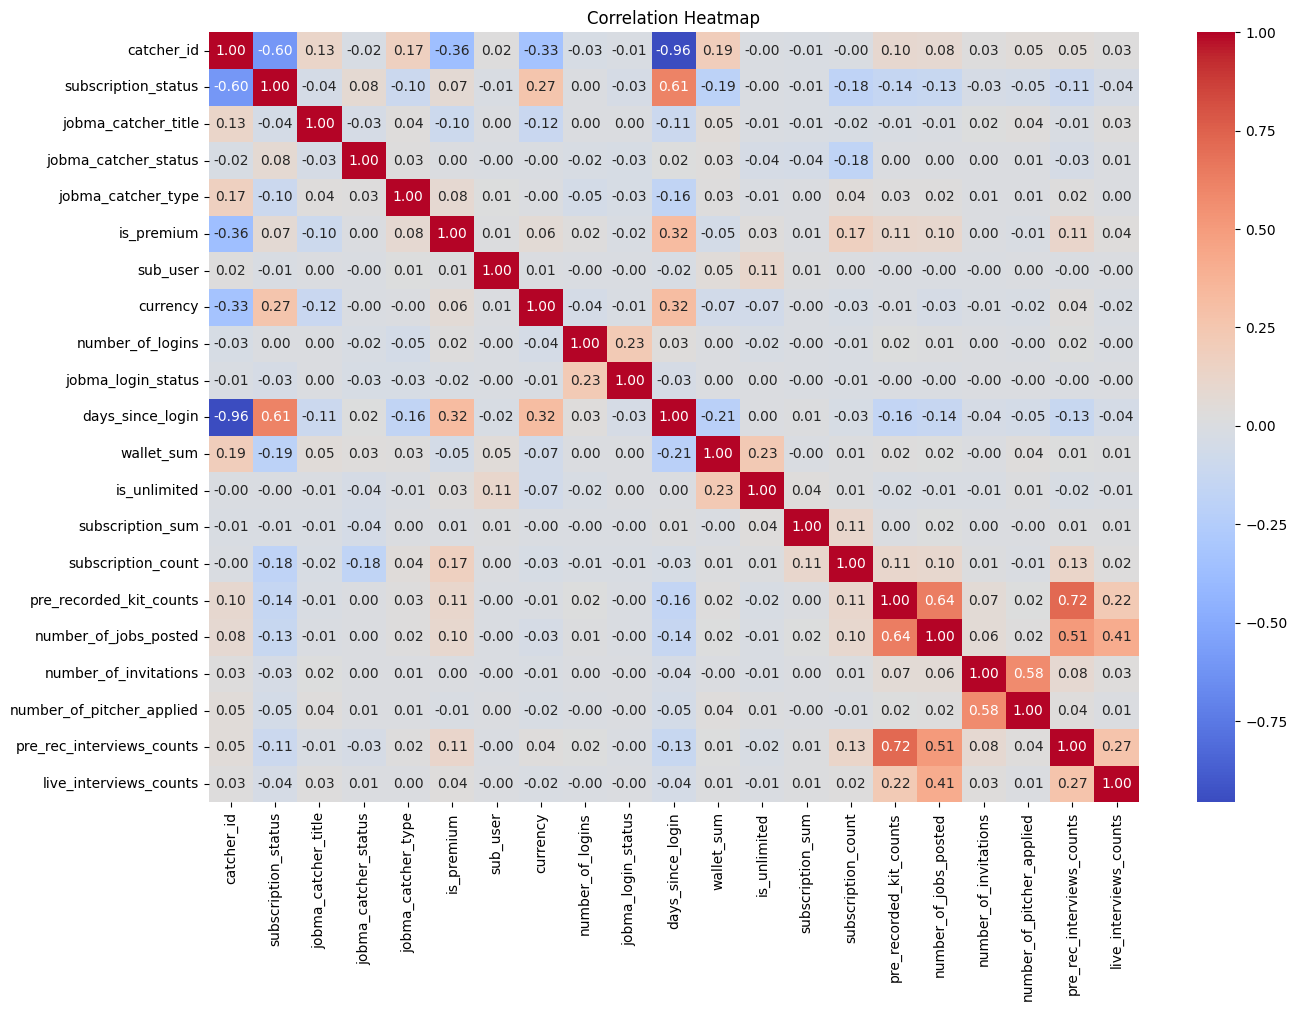

In [8]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [9]:
df = df.assign(**{f'log_{col}': np.log1p(df[col]) for col in ['sub_user',
                                                              'wallet_sum', 
                                                              'subscription_sum',
                                                              'subscription_count',
                                                              'pre_recorded_kit_counts',
                                                              'number_of_jobs_posted',
                                                              'number_of_invitations',
                                                              'number_of_invitations',
                                                              'number_of_pitcher_applied',
                                                              'pre_rec_interviews_counts', 
                                                              'live_interviews_counts']})


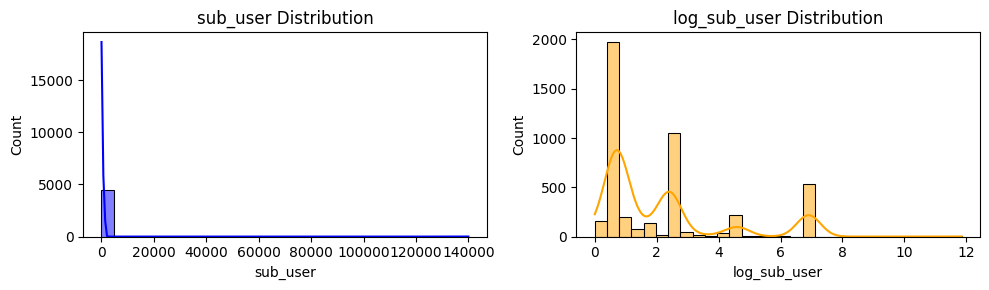

In [10]:
plot_side_by_side_histograms(df, 'sub_user', 'log_sub_user')

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
catcher_id,4466.00,6440.85,2131.81,2656.00,4654.25,6410.50,7876.75,10536.00
subscription_status,4466.00,1.75,0.43,1.00,2.00,2.00,2.00,2.00
jobma_catcher_title,4466.00,0.16,0.62,0.00,0.00,0.00,0.00,8.00
jobma_catcher_status,4466.00,0.94,0.23,0.00,1.00,1.00,1.00,1.00
jobma_catcher_type,4466.00,0.95,0.21,0.00,1.00,1.00,1.00,1.00
is_premium,4466.00,0.22,0.41,0.00,0.00,0.00,0.00,1.00
sub_user,4466.00,158.99,2117.39,0.00,1.00,2.00,10.00,140000.00
currency,4466.00,0.47,0.50,0.00,0.00,0.00,1.00,1.00
number_of_logins,4466.00,1.01,0.13,0.00,1.00,1.00,1.00,5.00
jobma_login_status,4466.00,0.00,0.03,0.00,0.00,0.00,0.00,1.00


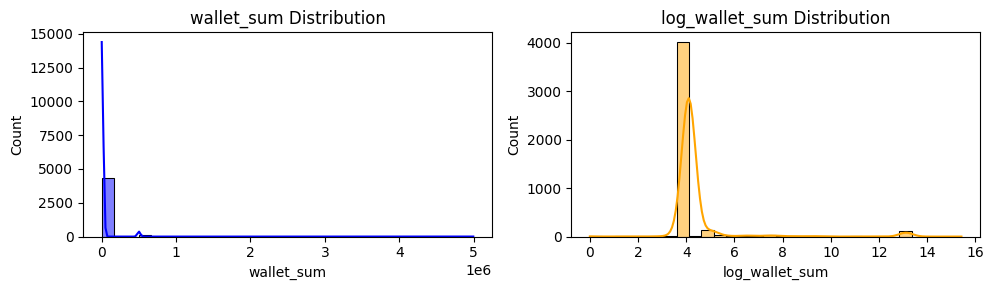

In [12]:
plot_side_by_side_histograms(df, 'wallet_sum', 'log_wallet_sum')

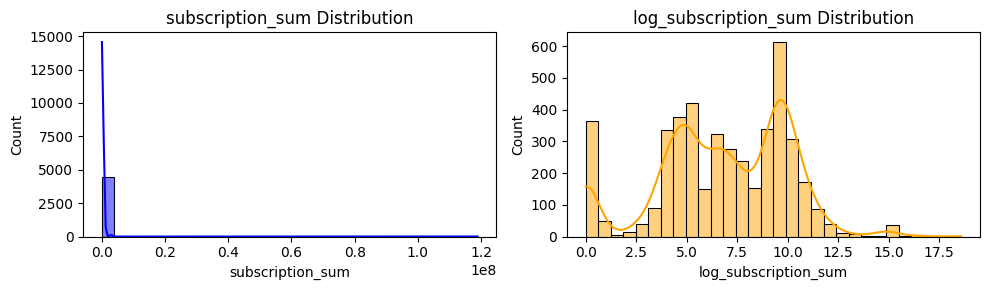

In [13]:
plot_side_by_side_histograms(df, 'subscription_sum', 'log_subscription_sum')

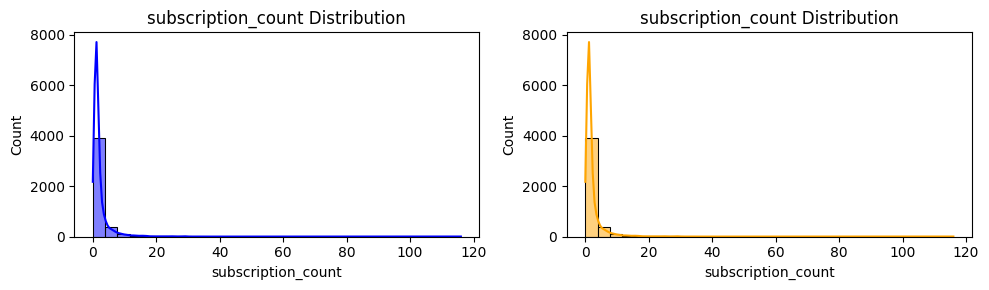

In [14]:
plot_side_by_side_histograms(df, 'subscription_count', 'subscription_count')

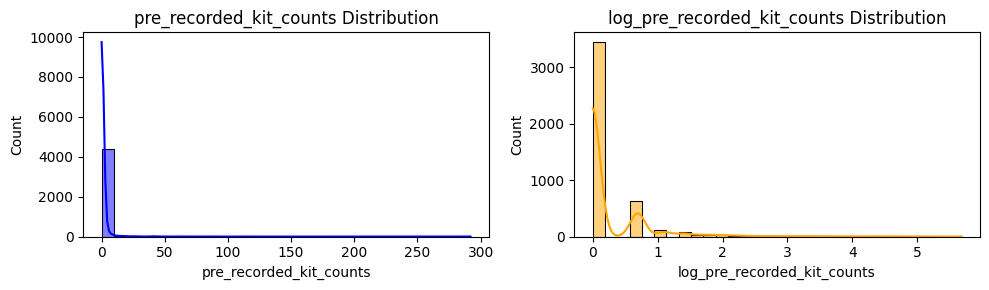

In [15]:
plot_side_by_side_histograms(df, 'pre_recorded_kit_counts', 'log_pre_recorded_kit_counts')

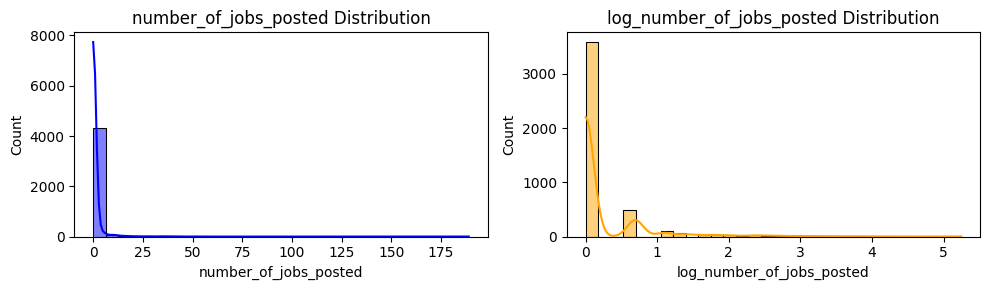

In [16]:
plot_side_by_side_histograms(df, 'number_of_jobs_posted', 'log_number_of_jobs_posted')

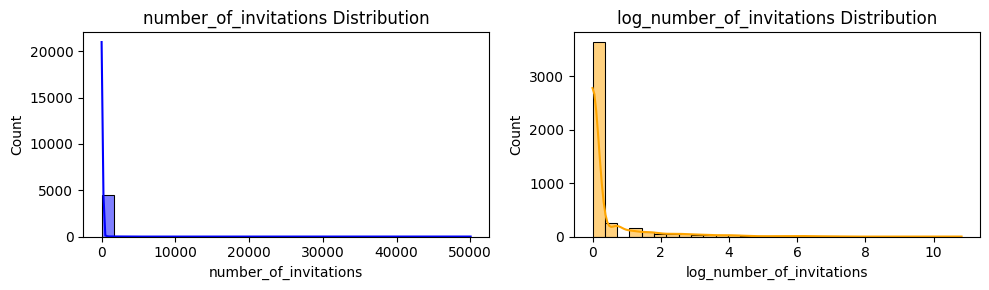

In [17]:
plot_side_by_side_histograms(df, 'number_of_invitations', 'log_number_of_invitations')

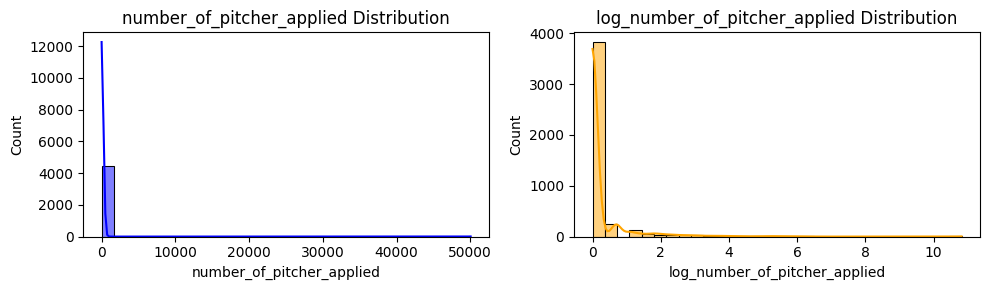

In [18]:
plot_side_by_side_histograms(df, 'number_of_pitcher_applied', 'log_number_of_pitcher_applied')

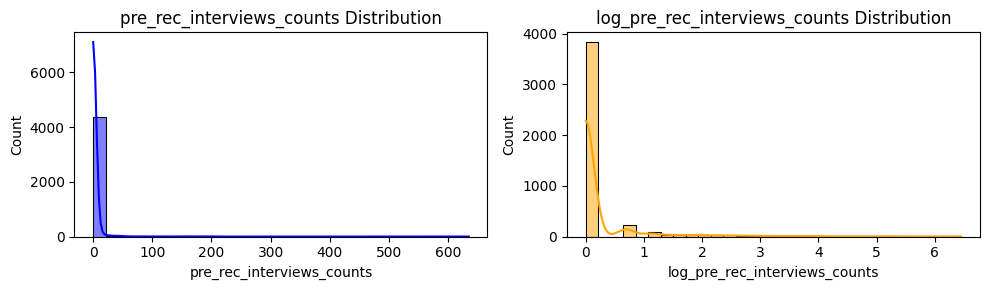

In [19]:
plot_side_by_side_histograms(df, 'pre_rec_interviews_counts', 'log_pre_rec_interviews_counts')